Two realities. Same world, different local floor.

In [3]:
from battery_fleet.compare import compare_runs
from battery_fleet.index import default_runs_dir, load_index

runs_dir = default_runs_dir()
success = [e for e in load_index(runs_dir) if e["status"] == "success"]
success.sort(key=lambda e: e["id"], reverse=True)
A = runs_dir / success[1]["id"]
B = runs_dir / success[0]["id"]

table = compare_runs(A, B)
print(table["a"])
print(table["b"])

{'revenue_usd': 60.68537499999955, 'shortfall_kwh': 11.011562500000073, 'coverage': 0.2957811219697376, 'locations_dark': 15, 'time_at_floor_s': 1271475}
{'revenue_usd': 104.93875, 'shortfall_kwh': 0.0, 'coverage': 1.0, 'locations_dark': 0, 'time_at_floor_s': 0}


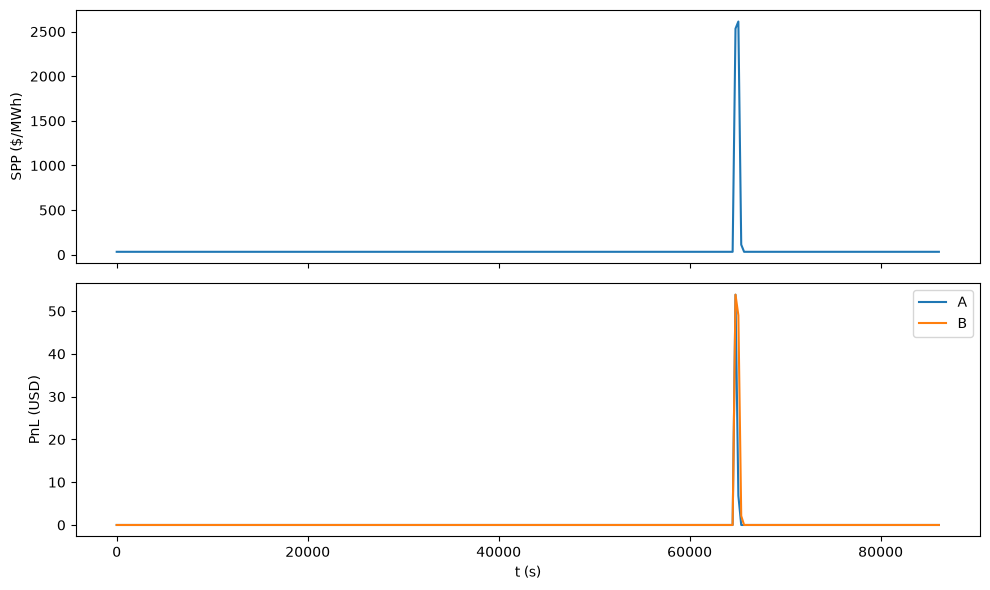

In [5]:
import matplotlib.pyplot as plt

iv_a = table["intervals"]["a"]
iv_b = table["intervals"]["b"]
ts = [row["t_s"] for row in iv_a]
spp = [row["spp"] for row in iv_a]
pnl_a = [row["pnl_usd"] for row in iv_a]
pnl_b = [row["pnl_usd"] for row in iv_b]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(ts, spp)
ax1.set_ylabel("SPP ($/MWh)")
ax2.plot(ts, pnl_a, label="A")
ax2.plot(ts, pnl_b, label="B")
ax2.set_ylabel("PnL (USD)")
ax2.legend()
ax2.set_xlabel("t (s)")
plt.tight_layout()
plt.show()